In [10]:
%pylab inline
!pip install keras-unet tensorflow_datasets

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['split']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [11]:
from keras_unet.models import custom_unet
from keras_unet.utils import plot_imgs
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
import glob

In [12]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

--2026-03-28 14:32:54--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-03-28 14:32:55--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz.1’

images.tar.gz.1     100%[===================>] 755.23M  41.3MB/s    in 19s     

2026-03-28 14:33:14 (39.3 MB/s) - ‘images.tar.gz.1’ saved [791918971/791918971]

--2026-03-28 14:33:14--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving w

In [13]:
## Gets the images, and masks using glob
img_files = sorted(glob.glob('images/Abyssinian_*.jpg'))
mask_files = sorted(glob.glob('annotations/trimaps/Abyssinian_*.png'))
images_list = []
masks_list = []

## opens image and mask, resizes them to 300 by 300. The Image.NEAREST parameter
## is so that the mask pixels aren't blended together.
for img_path, mask_path in zip(img_files, mask_files):
    img = np.array(Image.open(img_path).convert('L').resize((300, 300))) ## .convert('L') converts to grey scale
    segmentation = np.array(Image.open(mask_path).resize((300, 300), Image.NEAREST))
    images_list.append(img)
    masks_list.append((segmentation == 1).astype('f')) ## The original mask had 3 types, this converts it to binary with 1 being where its the pet and 0 when its not.

images = np.array(images_list) / 255.0
masks = np.array(masks_list)
print(images.shape, masks.shape)

(200, 300, 300) (200, 300, 300)


In [14]:
## pads the to 320 by 320 and splits up the images.

split = int(0.8 * len(images))

Images_train = np.pad(images[:split, ..., None], ((0,0),(10,10),(10,10),(0,0))) ##  images, height, width, channels
Masks_train = np.pad(masks[:split, ..., None],  ((0,0),(10,10),(10,10),(0,0)))
Images_test  = np.pad(images[split:, ..., None], ((0,0),(10,10),(10,10),(0,0)))
Masks_test  = np.pad(masks[split:, ..., None],  ((0,0),(10,10),(10,10),(0,0)))

print(Images_train.shape, Images_test.shape)

(160, 320, 320, 1) (40, 320, 320, 1)


In [15]:
model = custom_unet(input_shape=(320, 320, 1), dropout=0.3) ## builds unet with dropout
model.compile(loss='binary_crossentropy', optimizer='adam')

In [16]:
## Trains with Checkpointing and Earlystopping
history = model.fit(
    Images_train, Masks_train,
    validation_split=0.15,
    epochs=50,
    batch_size=8,
    callbacks=[
        ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
    ]
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.7544
Epoch 1: val_loss improved from None to 0.68134, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 240ms/step - loss: 0.6940 - val_loss: 0.6813
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.6198
Epoch 2: val_loss did not improve from 0.68134
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.6063 - val_loss: 1.0637
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.5614
Epoch 3: val_loss did not improve from 0.68134
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.5488 - val_loss: 11.5046
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.5210
Epoch 4: val_loss did not improve from 0.68134
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 0.5150 - val_loss: 0.7609
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.5000
Epoch 5: val_loss improved from 0.68134 to 0.65758, saving model to best_model.keras

Ep

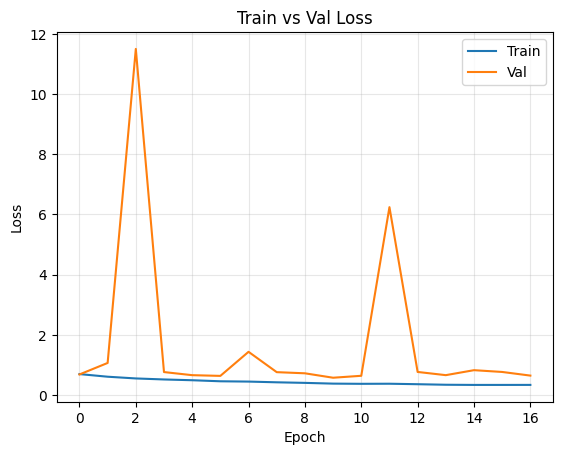

In [17]:
#plots training loss vs validation loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Train vs Val Loss')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 


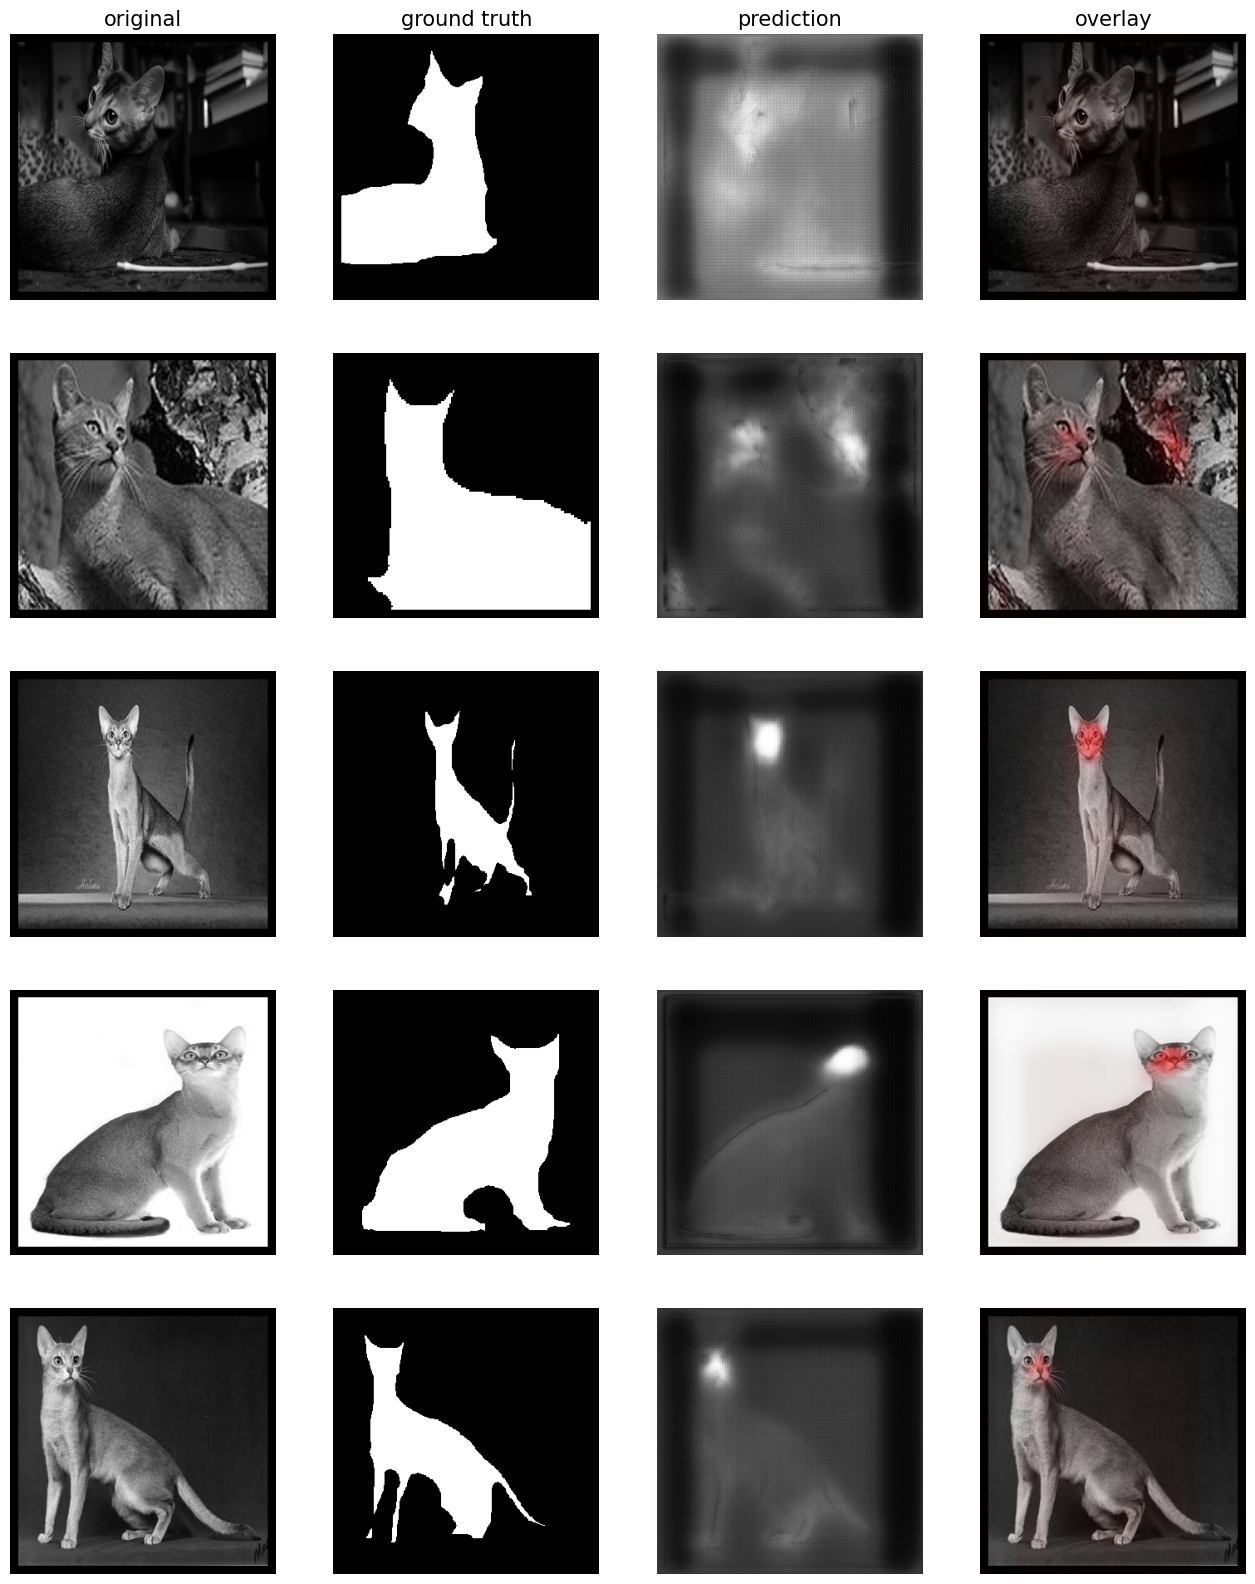

In [19]:
y_pred = model.predict(Images_test) ## Runs the model on the test images. Shows predictions with ground truth
plot_imgs(org_imgs=Images_test, mask_imgs=Masks_test, pred_imgs=y_pred, nm_img_to_plot=5)